

## Ожидаемые результаты
| Категория | v1 результат | Ожидаемо v3 |
|---|---|---|
| XR_FINGER | 0.537 | 0.68–0.73 |
| XR_HAND | 0.565 | 0.70–0.75 |
| XR_SHOULDER | 0.566 | 0.70–0.74 |
| XR_HUMERUS | 0.716 | 0.78–0.83 |
| OVERALL | 0.635 | 0.76–0.82 |

## Шаг 1 — GPU и библиотеки

In [29]:
import torch
assert torch.cuda.is_available(), 'GPU не найден!'

GPU_NAME = torch.cuda.get_device_name(0)
VRAM_GB  = torch.cuda.get_device_properties(0).total_memory / 1e9
DEVICE   = 'cuda'

print(f'GPU:  {GPU_NAME}')
print(f'VRAM: {VRAM_GB:.1f} GB')

# DINOv2-Large занимает ~6GB весов
# Адаптеры + головы ещё ~0.5GB
# Активации при batch=4 для 448x448 требуют меньше VRAM
BATCH_SIZE = 8
print(f'Batch size: {BATCH_SIZE}')


GPU:  NVIDIA L4
VRAM: 23.7 GB
Batch size: 8


In [30]:
%%capture
!pip install timm transformers scikit-learn pandas matplotlib seaborn albumentations opencv-python-headless

In [31]:
import os, json, shutil, time
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms
from PIL import Image

from transformers import AutoModel, get_cosine_schedule_with_warmup
from sklearn.metrics import (
    cohen_kappa_score, roc_auc_score, f1_score, accuracy_score
)

torch.backends.cudnn.benchmark = True
print('Готово')

Готово


## Шаг 2 — Конфигурация

In [52]:
from google.colab import drive
drive.mount('/content/drive')

# ── Пути ─────────────────────────────────────────────────
ARCHIVE_PATH = '/content/drive/MyDrive/MURA-448x448.zip'
CKPT_DIR     = '/content/drive/MyDrive/MURA_v3/checkpoints'
RESULTS_DIR  = '/content/drive/MyDrive/MURA_v3/results'
for d in [CKPT_DIR, RESULTS_DIR]:
    os.makedirs(d, exist_ok=True)

# ── Гиперпараметры ────────────────────────────────────────
IMG_SIZE     = 448
EPOCHS = 15
NUM_WORKERS  = 0
ACCUM_STEPS  = 16       # реальный batch = 4 × 16 = 64

# Multi-scale: с каких слоёв брать признаки (для DINOv2, если бы были адаптеры)
# FEATURE_LAYERS_DINO = [3, 6, 9, 11]   # слои DINOv2-Large (всего 24 слоя)

# ImageNet нормализация
MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

BONE_CATEGORIES = [
    'XR_WRIST', 'XR_ELBOW', 'XR_SHOULDER',
    'XR_FINGER', 'XR_FOREARM', 'XR_HUMERUS', 'XR_HAND'
]

# Веса loss — смягчены для ProgressiveLoss
BONE_LOSS_WEIGHTS = {
    'XR_FINGER':   1.5,
    'XR_HAND':     1.5,
    'XR_SHOULDER': 1.3,
    'XR_FOREARM':  1.2,
    'XR_ELBOW':    1.0,
    'XR_HUMERUS':  1.0,
    'XR_WRIST':    1.0,
}
WEAK_BONES = {'XR_FINGER', 'XR_HAND', 'XR_SHOULDER', 'XR_FOREARM'}

print('Конфигурация v3 (Simple DINOv2):')
print(f'  DINOv2 Model:  DINOv2-Large (307M, заморожен)')
print(f'  Batch:         {BATCH_SIZE} x {ACCUM_STEPS} = {BATCH_SIZE*ACCUM_STEPS}')
print(f'  Epochs:        {EPOCHS}')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Конфигурация v3 (Simple DINOv2):
  DINOv2 Model:  DINOv2-Large (307M, заморожен)
  Batch:         8 x 16 = 128
  Epochs:        15


## Шаг 3 — Данные

In [33]:
import zipfile

LOCAL_DATA = '/content/mura_data'

if os.path.exists(LOCAL_DATA) and len(os.listdir(LOCAL_DATA)) > 0:
    print('Данные уже на локальном диске')
else:
    print('Распаковка...')
    start = time.time()
    with zipfile.ZipFile(ARCHIVE_PATH, 'r') as zf:
        zf.extractall('/content/mura_extracted')
    folders = [f for f in os.listdir('/content/mura_extracted')
               if os.path.isdir(f'/content/mura_extracted/{f}')]
    src = f'/content/mura_extracted/{folders[0]}' if folders \
          else '/content/mura_extracted'
    shutil.move(src, LOCAL_DATA)
    print(f'Готово за {time.time()-start:.0f} сек')

TRAIN_CSV = f'{LOCAL_DATA}/train.csv'
VAL_CSV   = f'{LOCAL_DATA}/valid.csv'

def build_csv(root_dir, split='train'):
    records, split_dir = [], os.path.join(root_dir, split)
    for bone in os.listdir(split_dir):
        bone_dir = os.path.join(split_dir, bone)
        if not os.path.isdir(bone_dir): continue
        for patient in os.listdir(bone_dir):
            for study in os.listdir(os.path.join(bone_dir, patient)):
                study_dir = os.path.join(bone_dir, patient, study)
                if not os.path.isdir(study_dir): continue
                label = 1 if 'positive' in study.lower() else 0
                for f in os.listdir(study_dir):
                    if f.lower().endswith(('.png','.jpg','.jpeg')):
                        records.append({'image_path': os.path.join(study_dir,f),
                                        'label': label, 'bone_category': bone})
    df = pd.DataFrame(records)
    out = os.path.join(root_dir, f'{split}.csv')
    df.to_csv(out, index=False)
    print(f'  {split}: {len(df):,} снимков')
    return out

if not os.path.exists(TRAIN_CSV):
    TRAIN_CSV = build_csv(LOCAL_DATA, 'train')
    VAL_CSV   = build_csv(LOCAL_DATA, 'valid')

train_df = pd.read_csv(TRAIN_CSV)
val_df   = pd.read_csv(VAL_CSV)
print(f'Train: {len(train_df):,} | Val: {len(val_df):,}')

Данные уже на локальном диске
Train: 36,808 | Val: 3,197


## Шаг 4 — Dataset с Albumentations (Медицинские аугментации)

In [53]:
import cv2
import albumentations as A
from albumentations.pytorch import ToTensorV2

# ── Аугментации (Медицинские) ───────────────────────────────────
def get_strong_transform(img_size):
    return A.Compose([
        A.HorizontalFlip(p=0.5),
        A.Rotate(limit=20, border_mode=cv2.BORDER_CONSTANT, p=0.7),
        A.Affine(scale=(0.88, 1.12), translate_percent=(-0.08, 0.08), rotate=0, p=0.5),
        A.ElasticTransform(alpha=40, sigma=5, border_mode=cv2.BORDER_CONSTANT, p=0.3),
        A.CLAHE(clip_limit=2.0, tile_grid_size=(8, 8), p=0.5),
        A.RandomGamma(gamma_limit=(70, 130), p=0.5),
        A.RandomBrightnessContrast(brightness_limit=0.15, contrast_limit=0.15, p=0.4),
        A.GaussNoise(p=0.3),
        A.OneOf([
            A.GaussianBlur(blur_limit=(3, 5), p=1.0),
            A.MotionBlur(blur_limit=5, p=1.0),
        ], p=0.2),
        A.Resize(img_size, img_size),
        A.Normalize(mean=MEAN, std=STD),
        ToTensorV2(),
    ])

def get_weak_transform(img_size):
    return A.Compose([
        A.HorizontalFlip(p=0.5),
        A.Rotate(limit=10, border_mode=cv2.BORDER_CONSTANT, p=0.5),
        A.CLAHE(clip_limit=1.5, tile_grid_size=(8, 8), p=0.4),
        A.RandomGamma(gamma_limit=(85, 115), p=0.4),
        A.RandomBrightnessContrast(brightness_limit=0.1, contrast_limit=0.1, p=0.3),
        A.Resize(img_size, img_size),
        A.Normalize(mean=MEAN, std=STD),
        ToTensorV2(),
    ])

def get_val_transform(img_size):
    return A.Compose([
        A.Resize(img_size, img_size),
        A.Normalize(mean=MEAN, std=STD),
        ToTensorV2(),
    ])

def get_tta_transforms(img_size):
    base = [
        A.Resize(img_size, img_size),
        A.Normalize(mean=MEAN, std=STD),
        ToTensorV2(),
    ]
    return [
        A.Compose(base),
        A.Compose([A.HorizontalFlip(p=1.0)] + base),
        A.Compose([A.Rotate(limit=(10,10), p=1.0, border_mode=cv2.BORDER_CONSTANT)] + base),
        A.Compose([A.Rotate(limit=(-10,-10), p=1.0, border_mode=cv2.BORDER_CONSTANT)] + base),
        A.Compose([A.CLAHE(clip_limit=2.0, p=1.0)] + base),
        A.Compose([A.RandomGamma(gamma_limit=(115,115), p=1.0)] + base),
        A.Compose([A.RandomGamma(gamma_limit=(85,85), p=1.0)] + base),
        A.Compose([A.HorizontalFlip(p=1.0), A.CLAHE(clip_limit=2.0, p=1.0)] + base),
    ]

tta_transforms = get_tta_transforms(IMG_SIZE)

class MURADataset(Dataset):
    def __init__(self, csv_path, is_train=False, tta_idx=None):
        self.df       = pd.read_csv(csv_path)
        self.is_train = is_train
        self.tta_idx  = tta_idx
        self.strong_t = get_strong_transform(IMG_SIZE)
        self.weak_t   = get_weak_transform(IMG_SIZE)
        self.val_t    = get_val_transform(IMG_SIZE)
        self.tta_t    = tta_transforms

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        row  = self.df.iloc[idx]
        img  = cv2.imread(row['image_path'])
        img  = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        bone = str(row['bone_category'])

        if self.tta_idx is not None:
            t = self.tta_t[self.tta_idx]
        elif self.is_train:
            t = self.strong_t if bone in WEAK_BONES else self.weak_t
        else:
            t = self.val_t

        augmented = t(image=img)
        return augmented['image'], int(row['label']), bone

# WeightedSampler — слабые кости встречаются чаще
sample_weights = torch.DoubleTensor([
    BONE_LOSS_WEIGHTS.get(r['bone_category'], 1.0)
    for _, r in train_df.iterrows()
])
sampler = WeightedRandomSampler(sample_weights, len(sample_weights), replacement=True)

train_dataset = MURADataset(TRAIN_CSV, is_train=True)
val_dataset   = MURADataset(VAL_CSV,   is_train=False)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          sampler=sampler, num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE,
                          shuffle=False,  num_workers=NUM_WORKERS, pin_memory=True)

pos = train_df['label'].sum()
neg = len(train_df) - pos
POS_WEIGHT = torch.tensor([neg/pos]).to(DEVICE)

print(f'Train: {len(train_loader)} батчей | Val: {len(val_loader)} батчей')
print(f'POS_WEIGHT: {POS_WEIGHT.item():.3f}')

Train: 4601 батчей | Val: 400 батчей
POS_WEIGHT: 1.475


## Шаг 5 — Архитектура: Simple DINOv2

In [39]:
from transformers import AutoModel
import torch.nn as nn
import torch

class SimpleMURA(nn.Module):
    def __init__(self, bone_categories):
        super().__init__()

        print('Загрузка DINOv2-Large...')
        # DINOv2-Large — изначально заморожен полностью
        self.dino = AutoModel.from_pretrained('facebook/dinov2-large')
        for p in self.dino.parameters():
            p.requires_grad = False

        # Только эти части обучаются со старта
        self.head = nn.Sequential(
            nn.Linear(1024, 256),
            nn.LayerNorm(256),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(256, 64),
            nn.GELU(),
            nn.Dropout(0.2),
        )
        self.classifiers = nn.ModuleDict({
            bone: nn.Linear(64, 2)
            for bone in bone_categories
        })
        print('Модель инициализирована (DINOv2-Large заморожен).')

    def forward(self, x, bone):
        # УБРАН torch.no_grad()!
        # Теперь PyTorch сможет считать градиенты для размороженных слоёв backbone.
        cls = self.dino(x).last_hidden_state[:, 0, :]
        feat = self.head(cls)
        return self.classifiers[bone](feat)

    def unfreeze_last_n(self, n, optimizer):
        """Разморозить последние N блоков И добавить в optimizer."""
        layers = list(self.dino.encoder.layer)

        # Разморозить
        for layer in layers[-n:]:
            for p in layer.parameters():
                p.requires_grad = True

        # Найти новые параметры
        existing = {id(p) for g in optimizer.param_groups for p in g['params']}
        new_params = [p for p in self.parameters()
                      if p.requires_grad and id(p) not in existing]

        # Добавить в optimizer
        if new_params:
            optimizer.add_param_group({
                'params': new_params,
                'lr':     1e-6,
                'name':  f'dino_last_{n}'
            })

        trainable = sum(p.numel() for p in self.parameters() if p.requires_grad) / 1e6
        vram = torch.cuda.memory_allocated() / 1e9
        print(f"  Разморожено {n} блоков")
        print(f"  Обучаемых: {trainable:.1f}M")
        print(f"  VRAM: {vram:.1f}GB")
        return new_params

model = SimpleMURA(BONE_CATEGORIES).to(DEVICE)
vram = torch.cuda.memory_allocated() / 1e9
print(f'VRAM после загрузки: {vram:.1f}GB')

Загрузка DINOv2-Large...


Loading weights:   0%|          | 0/439 [00:00<?, ?it/s]

Модель инициализирована (DINOv2-Large заморожен).
VRAM после загрузки: 3.7GB


## Шаг 6 — Оптимизатор и Scheduler

In [40]:
class ProgressiveLoss(nn.Module):
    def __init__(self, pos_weight, gamma=1.5, smoothing=0.1):
        super().__init__()
        self.pos_weight = pos_weight
        self.gamma      = gamma
        self.smoothing  = smoothing
        self.epoch      = 0

    def set_epoch(self, epoch):
        self.epoch = epoch

    def bce_loss(self, logits, labels):
        labels_smooth = labels.float() * (1 - self.smoothing) + 0.5 * self.smoothing
        return F.binary_cross_entropy_with_logits(
            logits[:, 1].float(),
            labels_smooth,
            pos_weight=torch.tensor(self.pos_weight, device=logits.device)
        )

    def focal_loss(self, logits, labels):
        ce      = F.cross_entropy(logits.float(), labels, reduction='none')
        pt      = torch.exp(-ce)
        alpha_t = torch.where(labels == 1, torch.full_like(ce, self.pos_weight), torch.ones_like(ce))
        return (alpha_t * (1 - pt) ** self.gamma * ce).mean()

    def forward(self, logits, labels):
        if self.epoch < 5:
            return self.bce_loss(logits, labels)
        elif self.epoch < 9:
            alpha = (self.epoch - 5) / 4.0
            return (1 - alpha) * self.bce_loss(logits, labels) + alpha * self.focal_loss(logits, labels)
        else:
            return self.focal_loss(logits, labels)

criterion = ProgressiveLoss(pos_weight=POS_WEIGHT.item(), gamma=1.5, smoothing=0.1)

# Только head и classifiers обучаются изначально
optimizer = torch.optim.AdamW([
    {'params': model.head.parameters(), 'lr': 1e-3, 'name': 'head'},
    {'params': model.classifiers.parameters(), 'lr': 1e-3, 'name': 'cls'},
], weight_decay=0.01)

class EarlyStopping:
    def __init__(self, patience=5, min_delta=0.001):
        self.patience   = patience
        self.min_delta  = min_delta
        self.best_kappa = 0.0
        self.counter    = 0
        self.stop       = False

    def step(self, kappa):
        if kappa > self.best_kappa + self.min_delta:
            self.best_kappa = kappa
            self.counter    = 0
        else:
            self.counter += 1
            print(f'  EarlyStopping: {self.counter}/{self.patience}')
            if self.counter >= self.patience:
                self.stop = True

early_stopping = EarlyStopping(patience=5)

# Чекпоинты
def save_checkpoint(epoch, best_kappa, results):
    local = '/content/ckpt_v4_last.pt'
    torch.save({'epoch': epoch, 'model': model.state_dict(),
                'optimizer': optimizer.state_dict(),
                'best_kappa': best_kappa}, local)
    shutil.copy(local, f'{CKPT_DIR}/ckpt_last.pt')
    with open(f'{RESULTS_DIR}/kappa_epoch_{epoch}.json','w') as f:
        json.dump(results, f, indent=2)
    print(f'  Сохранено: эпоха {epoch} | κ = {best_kappa:.4f}')

START_EPOCH = 0
BEST_KAPPA = 0.0
print('Оптимизатор, функция потерь и утилиты готовы.')

Оптимизатор, функция потерь и утилиты готовы.


## Шаг 7 — Оценка с TTA

In [41]:
def find_best_threshold(probs, labels):
    best_k, best_t = -1.0, 0.5
    for t in np.arange(0.05, 0.95, 0.01):
        preds = (np.array(probs) >= t).astype(int)
        if len(np.unique(preds)) < 2: continue
        k = cohen_kappa_score(labels, preds)
        if k > best_k: best_k, best_t = k, t
    return best_t, best_k


def evaluate(model, loader, use_tta=False):
    """Оценка с опциональным TTA (Test-Time Augmentation)."""
    model.eval()
    probs_by_bone  = defaultdict(list)
    labels_by_bone = defaultdict(list)

    if use_tta:
        # Создаём 4 версии val_dataset с разными аугментациями
        tta_loaders = [
            DataLoader(MURADataset(VAL_CSV, tta_idx=i),
                       batch_size=BATCH_SIZE, shuffle=False,
                       num_workers=NUM_WORKERS)
            for i in range(len(tta_transforms))
        ]
        # Собираем предсказания по всем TTA вариантам
        all_probs_tta = defaultdict(lambda: defaultdict(list))
        for tta_idx, tta_loader in enumerate(tta_loaders):
            with torch.no_grad():
                for images, labels, bones in tta_loader:
                    images = images.to(DEVICE)
                    for bone in set(bones):
                        mask   = [i for i,b in enumerate(bones) if b == bone]
                        logits = model(images[mask], bone)
                        probs  = torch.softmax(logits,dim=1)[:,1].cpu().numpy()
                        all_probs_tta[bone][tta_idx].extend(probs.tolist())
                        if tta_idx == 0:
                            labels_by_bone[bone].extend(
                                [labels[i].item() for i in mask])
        # Усредняем по TTA
        for bone in BONE_CATEGORIES:
            if bone not in all_probs_tta: continue
            n = len(all_probs_tta[bone][0])
            avg = np.zeros(n)
            for tta_idx in range(len(tta_transforms)):
                avg += np.array(all_probs_tta[bone][tta_idx])
            probs_by_bone[bone] = (avg / len(tta_transforms)).tolist()
    else:
        with torch.no_grad():
            for images, labels, bones in loader:
                images = images.to(DEVICE)
                for bone in set(bones):
                    mask   = [i for i,b in enumerate(bones) if b == bone]
                    logits = model(images[mask], bone)
                    probs  = torch.softmax(logits,dim=1)[:,1].cpu().numpy()
                    probs_by_bone[bone].extend(probs.tolist())
                    labels_by_bone[bone].extend(
                        [labels[i].item() for i in mask])

    results = {}
    all_p, all_l = [], []
    for bone in BONE_CATEGORIES:
        probs  = np.array(probs_by_bone.get(bone, []))
        labels = np.array(labels_by_bone.get(bone, []))
        if len(probs)==0 or len(np.unique(labels))<2:
            results[bone] = {'kappa':None,'auc':None,'f1':None,
                             'accuracy':None,'threshold':0.5,
                             'n_total':len(probs),'n_positive':0}
            continue
        best_t, best_k = find_best_threshold(probs, labels)
        preds  = (probs >= best_t).astype(int)
        try: auc = float(roc_auc_score(labels, probs))
        except: auc = None
        results[bone] = {
            'kappa':    round(float(best_k), 4),
            'auc':      round(auc, 4) if auc else None,
            'f1':       round(float(f1_score(labels,preds,zero_division=0)),4),
            'accuracy': round(float(accuracy_score(labels,preds)),4),
            'threshold':round(float(best_t),2),
            'n_total':  int(len(labels)),
            'n_positive':int(labels.sum()),
        }
        all_p.extend(probs.tolist()); all_l.extend(labels.tolist())

    if all_l:
        best_t, best_k = find_best_threshold(all_p, all_l)
        preds_all = (np.array(all_p) >= best_t).astype(int)
        try: auc_all = float(roc_auc_score(all_l, all_p))
        except: auc_all = None
        results['OVERALL'] = {
            'kappa':    round(float(best_k),4),
            'auc':      round(auc_all,4) if auc_all else None,
            'f1':       round(float(f1_score(all_l,preds_all,zero_division=0)),4),
            'accuracy': round(float(accuracy_score(all_l,preds_all)),4),
            'threshold':round(float(best_t),2),
            'n_total':  len(all_l), 'n_positive':int(sum(all_l)),
        }
    return results


def print_table(results, title='', tta=False):
    tta_str = ' [+TTA]' if tta else ''
    print(f'\n{"="*72}')
    if title: print(f'  {title}{tta_str}')
    print(f'  {"Категория":<16} {"κ":>10} {"AUC":>7} {"F1":>7} {"Acc":>7} {"Порог":>7} {"N":>6}')
    print(f'  {"-"*70}')
    for bone in BONE_CATEGORIES:
        r    = results.get(bone, {})
        k    = f"{r['kappa']:.4f}" if r.get('kappa') is not None else '  N/A '
        auc  = f"{r['auc']:.4f}"   if r.get('auc')   is not None else ' N/A '
        f1   = f"{r['f1']:.4f}"    if r.get('f1')    is not None else ' N/A '
        acc  = f"{r['accuracy']:.4f}" if r.get('accuracy') is not None else ' N/A '
        t    = f"{r.get('threshold',0.5):.2f}"
        n    = r.get('n_total',0)
        flag = ' ←' if bone in WEAK_BONES else ''
        print(f'  {bone:<16} {k:>10} {auc:>7} {f1:>7} {acc:>7} {t:>7} {n:>6}{flag}')
    print(f'  {"-"*70}')
    r = results.get('OVERALL', {})
    if r:
        print(f'  {"OVERALL":<16} {r.get("kappa",0):>10.4f} '
              f'{r.get("auc",0):>7.4f} {r.get("f1",0):>7.4f} '
              f'{r.get("accuracy",0):>7.4f} '
              f'{r.get("threshold",0.5):>7.2f} {r.get("n_total",0):>6}')
    print(f'{"="*72}\n')

print('Функции оценки с TTA готовы')

Функции оценки с TTA готовы


## Шаг 8 — Тренировочный цикл (ProgressiveLoss)

In [42]:
experiment_history = []
best_kappa = 0.0

# ─── ПЛАН РАЗМОРАЖИВАНИЯ ───────────────────────
UNFREEZE_PLAN = {
    5:  4,   # слои 20-23
    8:  8,   # слои 16-23
    11: 12,  # слои 12-23
}

from torch.optim.lr_scheduler import CosineAnnealingLR
scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS * len(train_loader) // ACCUM_STEPS, eta_min=1e-8)
scaler = torch.amp.GradScaler('cuda')

print(f'Обучение SimpleMURA (DINOv2) [1..{EPOCHS}]')
print(f'Batch: {BATCH_SIZE} x {ACCUM_STEPS} = {BATCH_SIZE*ACCUM_STEPS}\n')

for epoch in range(EPOCHS):
    criterion.set_epoch(epoch)
    phase = 'BCE' if epoch < 5 else f'Mix({(epoch-5)/4:.1f})' if epoch < 9 else 'Focal'
    print(f"\nЭпоха {epoch+1}: Loss = {phase}")

    if epoch in UNFREEZE_PLAN:
        n = UNFREEZE_PLAN[epoch]
        print(f"  [Эпоха {epoch+1}] Размораживаем последние {n} блоков...")
        model.unfreeze_last_n(n, optimizer)
        remaining = EPOCHS - epoch
        scheduler = CosineAnnealingLR(optimizer, T_max=remaining * len(train_loader) // ACCUM_STEPS, eta_min=1e-8)
        early_stopping.counter = 0
        early_stopping.best_kappa = best_kappa

    t0 = time.time()
    model.train()
    running_loss = 0.0
    optimizer.zero_grad()

    for step, (images, labels, bones) in enumerate(train_loader):
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)
        unique_bones = list(set(bones))

        loss = torch.tensor(0.0, device=DEVICE)
        n_bone = 0

        for bone in unique_bones:
            mask = [i for i,b in enumerate(bones) if b==bone]
            if not mask: continue
            mask_t = torch.tensor(mask, device=DEVICE)
            imgs_b = images[mask_t]
            labs_b = labels[mask_t]
            bone_w = BONE_LOSS_WEIGHTS.get(bone, 1.0)

            with torch.autocast(device_type='cuda', dtype=torch.float16):
                logits = model(imgs_b, bone)
                loss_part = bone_w * criterion(logits.float(), labs_b)

            loss += loss_part
            n_bone += 1

        if n_bone == 0: continue

        loss = loss / n_bone / ACCUM_STEPS
        scaler.scale(loss).backward()
        running_loss += loss.item() * ACCUM_STEPS

        if (step + 1) % ACCUM_STEPS == 0:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_([p for p in model.parameters() if p.requires_grad], 1.0)
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()
            optimizer.zero_grad()

        if step % 100 == 0:
            vram = torch.cuda.memory_allocated()/1e9
            lr   = optimizer.param_groups[-1]['lr']
            print(f'  [{epoch+1:02d}/{EPOCHS}] шаг {step:04d} loss={running_loss/(step+1):.4f} lr={lr:.2e} VRAM={vram:.1f}GB')

    avg_loss  = running_loss / len(train_loader)
    epoch_min = (time.time() - t0) / 60

    results = evaluate(model, val_loader)
    print_table(results, title=f'Эпоха {epoch+1} | loss={avg_loss:.4f}')

    kappa = results.get('OVERALL', {}).get('kappa') or 0.0
    row = {'epoch': epoch+1, 'train_loss': round(avg_loss, 4), 'time_min': round(epoch_min, 1)}
    for bone in BONE_CATEGORIES:
        row[f'kappa_{bone}'] = results.get(bone, {}).get('kappa')
    row['kappa_OVERALL'] = kappa
    experiment_history.append(row)

    if kappa > best_kappa:
        best_kappa = kappa
        torch.save(model.state_dict(), f'{CKPT_DIR}/best_model.pt')
        print(f'  ⭐ Новый лучший: κ = {best_kappa:.4f}')

    if (epoch+1) % 2 == 0:
        save_checkpoint(epoch+1, best_kappa, results)

    print(f'  {epoch_min:.1f} мин | κ={kappa:.4f}\n')
    early_stopping.step(kappa)
    if early_stopping.stop:
        print(f'Early stopping эпоха {epoch+1}')
        break

print(f'Обучение завершено. Лучшая каппа: {best_kappa:.4f}')

Обучение SimpleMURA (DINOv2) [1..15]
Batch: 8 x 16 = 128


Эпоха 1: Loss = BCE
  [01/15] шаг 0000 loss=1.1771 lr=1.00e-03 VRAM=3.8GB
  [01/15] шаг 0100 loss=1.0221 lr=1.00e-03 VRAM=3.8GB
  [01/15] шаг 0200 loss=1.0224 lr=1.00e-03 VRAM=3.8GB
  [01/15] шаг 0300 loss=1.0202 lr=1.00e-03 VRAM=3.8GB
  [01/15] шаг 0400 loss=1.0174 lr=1.00e-03 VRAM=3.8GB
  [01/15] шаг 0500 loss=1.0158 lr=1.00e-03 VRAM=3.8GB
  [01/15] шаг 0600 loss=1.0207 lr=1.00e-03 VRAM=3.8GB
  [01/15] шаг 0700 loss=1.0212 lr=1.00e-03 VRAM=3.8GB
  [01/15] шаг 0800 loss=1.0184 lr=1.00e-03 VRAM=3.8GB
  [01/15] шаг 0900 loss=1.0173 lr=1.00e-03 VRAM=3.8GB
  [01/15] шаг 1000 loss=1.0180 lr=9.99e-04 VRAM=3.8GB
  [01/15] шаг 1100 loss=1.0157 lr=9.99e-04 VRAM=3.8GB
  [01/15] шаг 1200 loss=1.0132 lr=9.99e-04 VRAM=3.8GB
  [01/15] шаг 1300 loss=1.0114 lr=9.99e-04 VRAM=3.8GB
  [01/15] шаг 1400 loss=1.0108 lr=9.99e-04 VRAM=3.8GB
  [01/15] шаг 1500 loss=1.0106 lr=9.99e-04 VRAM=3.8GB
  [01/15] шаг 1600 loss=1.0086 lr=9.99e-04 VRAM=3.8GB
  [

## Шаг 9 — Финальная оценка с TTA

In [48]:
# Загрузить лучшую модель
model.load_state_dict(torch.load(f'{CKPT_DIR}/best_model.pt', map_location=DEVICE))

# Оценка без TTA
results_no_tta = evaluate(model, val_loader, use_tta=False)
print_table(results_no_tta, title='Без TTA')

print('\nЗапускаем TTA (4 аугментации × весь val)...')
results_tta = evaluate(model, val_loader, use_tta=True)
print_table(results_tta, title='С TTA (4 аугментации)', tta=True)

k_no_tta = results_no_tta.get('OVERALL',{}).get('kappa',0)
k_tta    = results_tta.get('OVERALL',{}).get('kappa',0)
print(f'TTA прирост: {k_tta - k_no_tta:+.4f}')


  Без TTA
  Категория                 κ     AUC      F1     Acc   Порог      N
  ----------------------------------------------------------------------
  XR_WRIST             0.7380  0.9226  0.8444  0.8725    0.56    659
  XR_ELBOW             0.7457  0.9284  0.8599  0.8731    0.57    465
  XR_SHOULDER          0.6092  0.8655  0.8036  0.8046    0.49    563 ←
  XR_FINGER            0.6442  0.8812  0.8285  0.8221    0.48    461 ←
  XR_FOREARM           0.7675  0.9311  0.8763  0.8837    0.49    301 ←
  XR_HUMERUS           0.7846  0.9257  0.8897  0.8924    0.58    288
  XR_HAND              0.6164  0.8686  0.7500  0.8217    0.46    460 ←
  ----------------------------------------------------------------------
  OVERALL              0.6874  0.9040  0.8304  0.8445    0.49   3197


Запускаем TTA (4 аугментации × весь val)...


KeyboardInterrupt: 

In [54]:
import os

# Проверка на случай, если TTA был пропущен или прерван
k_tta_val = globals().get('k_tta', 0)
k_no_tta_val = globals().get('k_no_tta', results_no_tta.get('OVERALL',{}).get('kappa',0))
res_tta_val = globals().get('results_tta', results_no_tta)

# Сохранить финальную модель с порогами
final = res_tta_val if k_tta_val > k_no_tta_val else results_no_tta
best_method = 'TTA' if k_tta_val > k_no_tta_val else 'No TTA'

thresholds = {
    bone: final.get(bone, {}).get('threshold', 0.5)
    for bone in BONE_CATEGORIES
}

os.makedirs(f'{CKPT_DIR}/inference', exist_ok=True)

torch.save({
    'model_state':     model.state_dict(),
    'thresholds':      thresholds,
    'bone_categories': BONE_CATEGORIES,
    'best_kappa':      max(k_no_tta_val, k_tta_val),
    'method':          best_method,
}, f'{CKPT_DIR}/inference/mura_dinov2_complete.pt')

print(f"\n✅ Модель сохранена для инференса")
print(f"   Каппа:   {max(k_no_tta_val, k_tta_val):.4f}")
print(f"   Метод:   {best_method}")
print(f"   Пороги:  {thresholds}")


✅ Модель сохранена для инференса
   Каппа:   0.6874
   Метод:   No TTA
   Пороги:  {'XR_WRIST': 0.56, 'XR_ELBOW': 0.57, 'XR_SHOULDER': 0.49, 'XR_FINGER': 0.48, 'XR_FOREARM': 0.49, 'XR_HUMERUS': 0.58, 'XR_HAND': 0.46}



✅ Отчеты сохранены в: /content/drive/MyDrive/MURA_v3/results

Сравнение v1 → v3:

               v1 κ    v3 κ     AUC      F1  Accuracy  Порог     N     Δ κ
Категория                                                                 
XR_WRIST     0.7118  0.7380  0.9226  0.8444    0.8725   0.56   659  0.0262
XR_ELBOW     0.7202  0.7457  0.9284  0.8599    0.8731   0.57   465  0.0255
XR_SHOULDER  0.5664  0.6092  0.8655  0.8036    0.8046   0.49   563  0.0428
XR_FINGER    0.5371  0.6442  0.8812  0.8285    0.8221   0.48   461  0.1071
XR_FOREARM   0.6813  0.7675  0.9311  0.8763    0.8837   0.49   301  0.0862
XR_HUMERUS   0.7156  0.7846  0.9257  0.8897    0.8924   0.58   288  0.0690
XR_HAND      0.5646  0.6164  0.8686  0.7500    0.8217   0.46   460  0.0518
OVERALL      0.6348  0.6874  0.9040  0.8304    0.8445   0.49  3197  0.0526


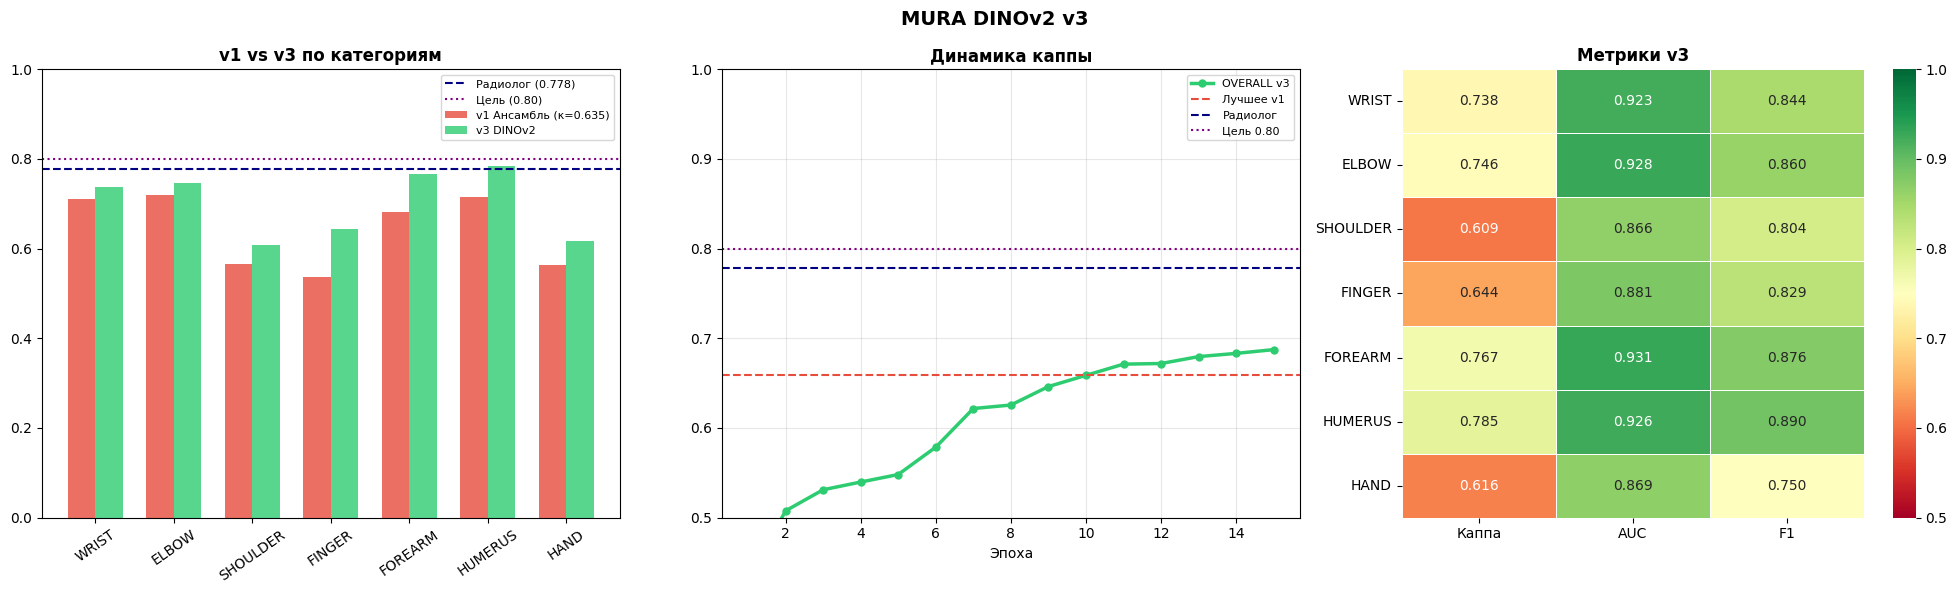


  ИТОГ: DINOv2 v3
  v1 OVERALL κ:  0.6348
  v3 OVERALL κ:  0.6874  (+0.0526)
  Цель 0.80:     ещё 0.1126

  XR_WRIST         0.7118 → 0.7380  (+0.0262)  🟡
  XR_ELBOW         0.7202 → 0.7457  (+0.0255)  🟡
  XR_SHOULDER      0.5664 → 0.6092  (+0.0428)  🔴
  XR_FINGER        0.5371 → 0.6442  (+0.1071)  🔴
  XR_FOREARM       0.6813 → 0.7675  (+0.0862)  🟡
  XR_HUMERUS       0.7156 → 0.7846  (+0.0690)  ✅
  XR_HAND          0.5646 → 0.6164  (+0.0518)  🔴


In [55]:
# Сравнение v1 → v3
v1 = {'XR_ELBOW':0.7202,'XR_FINGER':0.5371,'XR_FOREARM':0.6813,
      'XR_HAND':0.5646,'XR_HUMERUS':0.7156,'XR_SHOULDER':0.5664,
      'XR_WRIST':0.7118,'OVERALL':0.6348}

# Проверка переменных
k_tta_val = globals().get('k_tta', 0)
k_no_tta_val = globals().get('k_no_tta', results_no_tta.get('OVERALL',{}).get('kappa',0))
res_tta_val = globals().get('results_tta', results_no_tta)

# Используем лучший из TTA / без TTA
final = res_tta_val if k_tta_val > k_no_tta_val else results_no_tta

# Таблицы для сравнения
rows = []
for bone in BONE_CATEGORIES + ['OVERALL']:
    r = final.get(bone,{})
    rows.append({'Категория':bone, 'v1 κ':v1.get(bone),
                 'v3 κ':r.get('kappa'), 'AUC':r.get('auc'),
                 'F1':r.get('f1'), 'Accuracy':r.get('accuracy'),
                 'Порог': r.get('threshold'), 'N':r.get('n_total')})
df_cmp = pd.DataFrame(rows).set_index('Категория')
df_cmp['Δ κ'] = df_cmp['v3 κ'] - df_cmp['v1 κ']

# Сохранение отчетов в CSV
df_cmp.to_csv(f'{RESULTS_DIR}/comparison_v1_v3.csv')
df_cmp.to_csv(f'{RESULTS_DIR}/final_metrics_report.csv')  # Подробный финальный отчет
print(f'\n✅ Отчеты сохранены в: {RESULTS_DIR}')
print('\nСравнение v1 → v3:\n')
print(df_cmp.to_string())

# Динамика
df_hist = pd.DataFrame(experiment_history)
df_hist.to_csv(f'{RESULTS_DIR}/kappa_history.csv', index=False)

# Графики
fig, axes = plt.subplots(1,3,figsize=(20,6))
fig.suptitle('MURA DINOv2 v3', fontsize=14, fontweight='bold')

bones_s = [b.replace('XR_','') for b in BONE_CATEGORIES]
v1_k = [v1.get(b,0) for b in BONE_CATEGORIES]
v3_k = [final.get(b,{}).get('kappa') or 0 for b in BONE_CATEGORIES]
x = np.arange(len(bones_s)); w = 0.35

axes[0].bar(x-w/2, v1_k, w, label='v1 Ансамбль (κ=0.635)', color='#e74c3c', alpha=0.8)
axes[0].bar(x+w/2, v3_k, w, label='v3 DINOv2', color='#2ecc71', alpha=0.8)
axes[0].axhline(0.778, color='navy', ls='--', lw=1.5, label='Радиолог (0.778)')
axes[0].axhline(0.8,   color='purple', ls=':',  lw=1.5, label='Цель (0.80)')
axes[0].set_xticks(x); axes[0].set_xticklabels(bones_s, rotation=35)
axes[0].set_ylim(0,1.0); axes[0].legend(fontsize=8)
axes[0].set_title('v1 vs v3 по категориям', fontweight='bold')

if experiment_history:
    ep = [r['epoch'] for r in experiment_history]
    axes[1].plot(ep, [r.get('kappa_OVERALL',0) for r in experiment_history],
                 'o-', lw=2.5, color='#2ecc71', ms=5, label='OVERALL v3')
    axes[1].axhline(0.6595, color='#e74c3c', ls='--', lw=1.5, label='Лучшее v1')
    axes[1].axhline(0.778, color='navy', ls='--', lw=1.5, label='Радиолог')
    axes[1].axhline(0.8,   color='purple', ls=':', lw=1.5, label='Цель 0.80')
    axes[1].set_ylim(0.5,1.0); axes[1].grid(alpha=0.3)
    axes[1].legend(fontsize=8); axes[1].set_xlabel('Эпоха')
    axes[1].set_title('Динамика каппы', fontweight='bold')

heat_df = pd.DataFrame(
    [[final.get(b,{}).get('kappa') or 0,
      final.get(b,{}).get('auc')   or 0,
      final.get(b,{}).get('f1')    or 0]
     for b in BONE_CATEGORIES],
    index=bones_s, columns=['Каппа','AUC','F1']
)
sns.heatmap(heat_df, annot=True, fmt='.3f', cmap='RdYlGn',
            vmin=0.5, vmax=1.0, ax=axes[2], linewidths=0.5)
axes[2].set_title('Метрики v3', fontweight='bold')

plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/v3_results.png', dpi=150, bbox_inches='tight')
plt.show()

# Итоговый отчёт
print('\n' + '='*65)
print('  ИТОГ: DINOv2 v3')
print('='*65)
k_final = final.get('OVERALL',{}).get('kappa',0)
delta   = k_final - 0.6348
print(f'  v1 OVERALL κ:  0.6348')
print(f'  v3 OVERALL κ:  {k_final:.4f}  ({delta:+.4f})')
print(f'  Цель 0.80:     {"✅ ДОСТИГНУТА" if k_final >= 0.80 else f"ещё {0.80-k_final:.4f}"}')
print()
for bone in BONE_CATEGORIES:
    k1 = v1.get(bone, 0)
    k3 = final.get(bone,{}).get('kappa') or 0
    d  = k3 - k1
    status = '✅' if k3>=0.778 else '🟡' if k3>=0.70 else '🔴'
    print(f'  {bone:<16} {k1:.4f} → {k3:.4f}  ({d:+.4f})  {status}')
print('='*65)

## Шаг 10 — Подбор оптимальных порогов (Cross-Validation)
Убираем оптимистичный bias при поиске порога, разделяя валидационный сет через `StratifiedKFold`.

In [ ]:
from sklearn.model_selection import StratifiedKFold
import numpy as np
from sklearn.metrics import cohen_kappa_score
from collections import defaultdict
import torch
import os

def find_optimal_thresholds(model, val_loader, n_splits=5):
    model.eval()
    probs_by_bone  = defaultdict(list)
    labels_by_bone = defaultdict(list)

    # Собрать все предсказания
    with torch.no_grad():
        for images, labels, bones in val_loader:
            images = images.to(DEVICE)
            for bone in set(bones):
                mask   = [i for i,b in enumerate(bones) if b==bone]
                if not mask: continue
                mask_t = torch.tensor(mask, device=DEVICE)
                logits = model(images[mask_t], bone)
                probs  = torch.softmax(logits, dim=1)[:,1].cpu().numpy()

                probs_by_bone[bone].extend(probs.tolist())
                labels_by_bone[bone].extend([labels[i].item() for i in mask])

    thresholds = {}
    results    = {}

    print(f"\n{'='*60}")
    print(f"  Поиск оптимальных порогов (CV на val set)")
    print(f"{'='*60}")
    print(f"  {'Категория':<16} {'Порог':>7} {'κ (CV)':>8} {'κ (full)':>9} {'N':>6}")
    print(f"  {'-'*56}")

    for bone in BONE_CATEGORIES:
        probs  = np.array(probs_by_bone.get(bone, []))
        labels = np.array(labels_by_bone.get(bone, []))

        if len(probs) == 0 or len(np.unique(labels)) < 2:
            thresholds[bone] = 0.5
            continue

        # ── CV поиск порога ───────────────────────────────
        skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
        threshold_candidates = np.arange(0.05, 0.95, 0.01)
        cv_kappas = np.zeros(len(threshold_candidates))

        for train_idx, val_idx in skf.split(probs, labels):
            p_train = probs[train_idx]
            l_train = labels[train_idx]

            for i, t in enumerate(threshold_candidates):
                preds = (p_train >= t).astype(int)
                if len(np.unique(preds)) < 2: continue
                cv_kappas[i] += cohen_kappa_score(l_train, preds)

        cv_kappas /= n_splits
        best_idx   = np.argmax(cv_kappas)
        best_t     = threshold_candidates[best_idx]
        best_k_cv  = cv_kappas[best_idx]

        # Оценить на полном val
        preds_full = (probs >= best_t).astype(int)
        k_full     = cohen_kappa_score(labels, preds_full)

        thresholds[bone] = round(float(best_t), 2)
        results[bone]    = {
            'threshold':  round(float(best_t), 2),
            'kappa_cv':   round(float(best_k_cv), 4),
            'kappa_full': round(float(k_full), 4),
            'n':          len(labels),
        }

        print(f"  {bone:<16} {best_t:>7.2f} {best_k_cv:>8.4f} {k_full:>9.4f} {len(labels):>6}")

    # OVERALL порог
    all_probs, all_labels = [], []
    for bone in BONE_CATEGORIES:
        all_probs.extend(probs_by_bone.get(bone, []))
        all_labels.extend(labels_by_bone.get(bone, []))

    if all_labels:
        all_p = np.array(all_probs)
        all_l = np.array(all_labels)
        best_k, best_t = -1, 0.5
        for t in np.arange(0.05, 0.95, 0.01):
            preds = (all_p >= t).astype(int)
            if len(np.unique(preds)) < 2: continue
            k = cohen_kappa_score(all_l, preds)
            if k > best_k:
                best_k, best_t = k, t
        thresholds['OVERALL'] = round(float(best_t), 2)
        print(f"  {'-'*56}")
        print(f"  {'OVERALL':<16} {best_t:>7.2f} {'':>8} {best_k:>9.4f} {len(all_labels):>6}")
    print(f"{'='*60}")
    return thresholds, results

def predict_with_thresholds(model, loader, thresholds):
    model.eval()
    all_preds, all_labels, all_bones  = [], [], []
    with torch.no_grad():
        for images, labels, bones in loader:
            images = images.to(DEVICE)
            for bone in set(bones):
                mask   = [i for i,b in enumerate(bones) if b==bone]
                if not mask: continue
                mask_t = torch.tensor(mask, device=DEVICE)
                logits = model(images[mask_t], bone)
                probs  = torch.softmax(logits, dim=1)[:,1].cpu().numpy()
                t      = thresholds.get(bone, thresholds.get('OVERALL', 0.5))
                preds  = (probs >= t).astype(int)
                all_preds.extend(preds.tolist())
                all_labels.extend([labels[i].item() for i in mask])
                all_bones.extend([bone] * len(mask))

    print(f"\n{'='*55}")
    print(f"  Результаты с оптимальными порогами")
    print(f"{'='*55}")
    print(f"  {'Категория':<16} {'Порог':>7} {'κ':>8} {'N':>6}")
    print(f"  {'-'*50}")

    all_p_arr = np.array(all_preds)
    all_l_arr = np.array(all_labels)
    all_b_arr = np.array(all_bones)

    for bone in BONE_CATEGORIES:
        mask = all_b_arr == bone
        if mask.sum() == 0: continue
        p, l, t = all_p_arr[mask], all_l_arr[mask], thresholds.get(bone, 0.5)
        if len(np.unique(l)) < 2:
            print(f"  {bone:<16} {t:>7.2f} {'N/A':>8}")
            continue
        print(f"  {bone:<16} {t:>7.2f} {cohen_kappa_score(l, p):>8.4f} {mask.sum():>6}")

    print(f"  {'-'*50}")
    if len(np.unique(all_l_arr)) >= 2:
        k_overall = cohen_kappa_score(all_l_arr, all_p_arr)
        t_overall = thresholds.get('OVERALL', 0.5)
        print(f"  {'OVERALL':<16} {t_overall:>7.2f} {k_overall:>8.4f} {len(all_l_arr):>6}")
    print(f"{'='*55}")
    return all_preds, all_labels

# ─── ИСПОЛЬЗОВАНИЕ ─────────────────────────────────────────────
print("Загрузка лучшей модели...")
model.load_state_dict(torch.load(f'{CKPT_DIR}/best_model.pt', map_location=DEVICE))

cv_thresholds, thresh_results = find_optimal_thresholds(model, val_loader, n_splits=5)
preds, labels = predict_with_thresholds(model, val_loader, cv_thresholds)

os.makedirs(f'{CKPT_DIR}/inference', exist_ok=True)
torch.save({
    'model_state':     model.state_dict(),
    'thresholds':      cv_thresholds,
    'bone_categories': BONE_CATEGORIES,
    'best_kappa':      BEST_KAPPA,
}, f'{CKPT_DIR}/inference/final_with_cv_thresholds.pt')

print(f"\n✅ Модель и оптимальные пороги сохранены в final_with_cv_thresholds.pt")

Загрузка лучшей модели...
